### IND320 project work part 1 
Name: Mina Johanne Askerød <br>
Date: 28.09.2026 <br>
GitHub link: https://github.com/Minajohanne/IND320_project_Minajohanne <br>
Streamlit link: https://ind320projectminajohanne.streamlit.app/<br>
Recording link: https://nmbu.cloud.panopto.eu/Panopto/Pages/Viewer.aspx?id=9c1bb640-9aff-47b8-83c9-b4d300f146c1


#### Import packages 

In [1]:
# data handling 
import pandas as pd

# visualizations 
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt



#### Reading the data

In [2]:
# reading in the data 
dat = pd.read_csv('../data/reservoirs.csv') 
dat.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


#### Data exploration

In [3]:
# dimensions 
dat.shape 

(14877, 11)

In [4]:
dat.describe()

,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,fyllingsgrad_forrige_uke,endring_fyllingsgrad
count,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000
mean,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,0.618890,-0.000038
std,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,0.214843,0.031385
min,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,0.055160,-0.242484
25%,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,0.456356,-0.022395
50%,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,0.648114,-0.007072
75%,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,0.802133,0.016277
max,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,1.020037,0.336623


In [5]:
dat.info()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dato_Id                   14877 non-null  str    
 1   omrType                   14877 non-null  str    
 2   omrnr                     14877 non-null  int64  
 3   iso_aar                   14877 non-null  int64  
 4   iso_uke                   14877 non-null  int64  
 5   fyllingsgrad              14877 non-null  float64
 6   kapasitet_TWh             14877 non-null  float64
 7   fylling_TWh               14877 non-null  float64
 8   neste_Publiseringsdato    14877 non-null  str    
 9   fyllingsgrad_forrige_uke  14877 non-null  float64
 10  endring_fyllingsgrad      14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB


Renaming the column names to english and understandable names. 

In [6]:
# map names dictionary
map_names = {
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "filling_level",
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "stored_energy_TWh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "filling_level_previous_week",
    "endring_fyllingsgrad": "change_in_filling_level"
}  

# map names
dat = dat.rename(columns=map_names)  

Converting column "date" to a datetime object and sorting the dates. 

In [7]:
dat["date"].dtype

<StringDtype(na_value=nan)>

In [8]:
# convert date to a datetime object 
dat["date"] = pd.to_datetime(dat["date"])
dat["date"].dtype

dtype('<M8[us]')

In [9]:
dat = dat.sort_values("date")
dat.head()

,date,area_type,area_number,iso_year,iso_week,filling_level,capacity_TWh,stored_energy_TWh,next_publication_date,filling_level_previous_week,change_in_filling_level
3468,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160
3361,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
5036,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
3113,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
7739,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657


In [10]:
dat.tail()

,date,area_type,area_number,iso_year,iso_week,filling_level,capacity_TWh,stored_energy_TWh,next_publication_date,filling_level_previous_week,change_in_filling_level
8263,2026-09-06,EL,4,2026,36,0.902762,21.079208,19.029512,2026-09-16T13:00:00,0.906918,-0.004156
14875,2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16T13:00:00,0.567087,0.003310
14873,2026-09-06,VASS,3,2026,36,0.826252,28.155403,23.263466,2026-09-16T13:00:00,0.827641,-0.001389
8264,2026-09-06,EL,2,2026,36,0.460863,34.043590,15.689445,2026-09-16T13:00:00,0.458999,0.001865
14876,2026-09-06,VASS,2,2026,36,0.516978,23.237715,12.013381,2026-09-16T13:00:00,0.514423,0.002555


In [11]:
(dat["next_publication_date"] == "0001-01-01T00:00:00").sum()

np.int64(11322)

In [12]:
placeholder = dat[
    dat["next_publication_date"] == "0001-01-01T00:00:00"
]

# Count placeholder dates per year
placeholder_counts = (
    placeholder.groupby("iso_year")
    .size()
    .reset_index(name="count")
)
placeholder_counts

,iso_year,count
0,1995,468
1,1996,468
2,1997,468
3,1998,477
4,1999,468
5,2000,468
6,2001,468
7,2002,468
8,2003,468
9,2004,477


The value "0001-01-01T00:00:00" in column "next_publication_date" does not represent a publication date, but seems to be a placeholder for missing publication dates. I therefore convert these values to NaT (not a time), which is pandas´representation of missing datetime values. 

In [13]:
# Replace placeholder dates with missing values
dat["next_publication_date"] = dat["next_publication_date"].replace(
    "0001-01-01T00:00:00",
    pd.NA
)

In [14]:
dat.tail()

,date,area_type,area_number,iso_year,iso_week,filling_level,capacity_TWh,stored_energy_TWh,next_publication_date,filling_level_previous_week,change_in_filling_level
8263,2026-09-06,EL,4,2026,36,0.902762,21.079208,19.029512,2026-09-16T13:00:00,0.906918,-0.004156
14875,2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16T13:00:00,0.567087,0.003310
14873,2026-09-06,VASS,3,2026,36,0.826252,28.155403,23.263466,2026-09-16T13:00:00,0.827641,-0.001389
8264,2026-09-06,EL,2,2026,36,0.460863,34.043590,15.689445,2026-09-16T13:00:00,0.458999,0.001865
14876,2026-09-06,VASS,2,2026,36,0.516978,23.237715,12.013381,2026-09-16T13:00:00,0.514423,0.002555


Exploring number of observations for each area number and each area type, and combinations of these. 

In [15]:
# distribution over areas 
dat["area_number"].value_counts() 

area_number
3    3306
1    3306
2    3306
5    1653
4    1653
0    1653
Name: count, dtype: int64

In [16]:
# distributions across area types
dat["area_type"].value_counts()

area_type
EL      8265
VASS    4959
NO      1653
Name: count, dtype: int64

In [17]:
# distributions across area types and area numbers
dat[["area_type", "area_number"]].drop_duplicates().sort_values(
    ["area_type", "area_number"]
)

,area_type,area_number
3113,EL,1
7739,EL,2
5036,EL,3
3361,EL,4
3468,EL,5
8501,NO,0
14162,VASS,1
11380,VASS,2
11198,VASS,3


#### Visualizations

##### Plot of each column

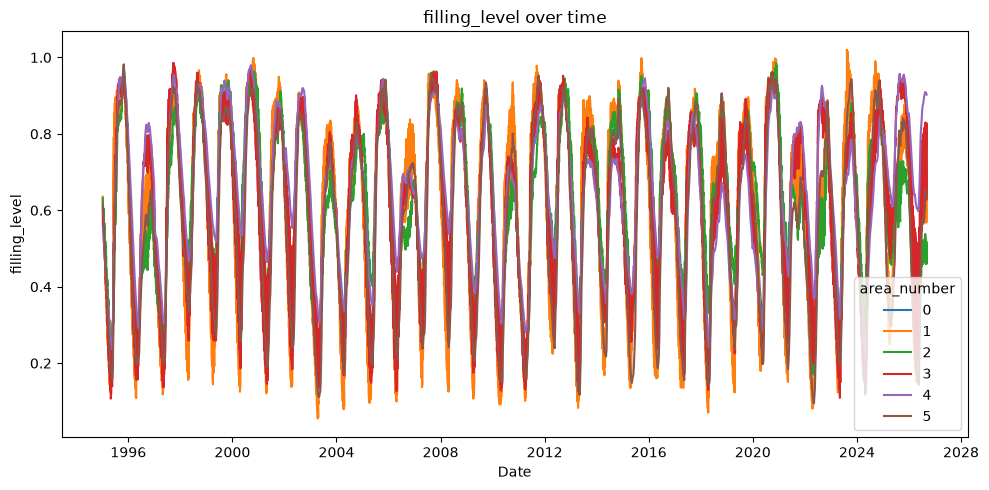

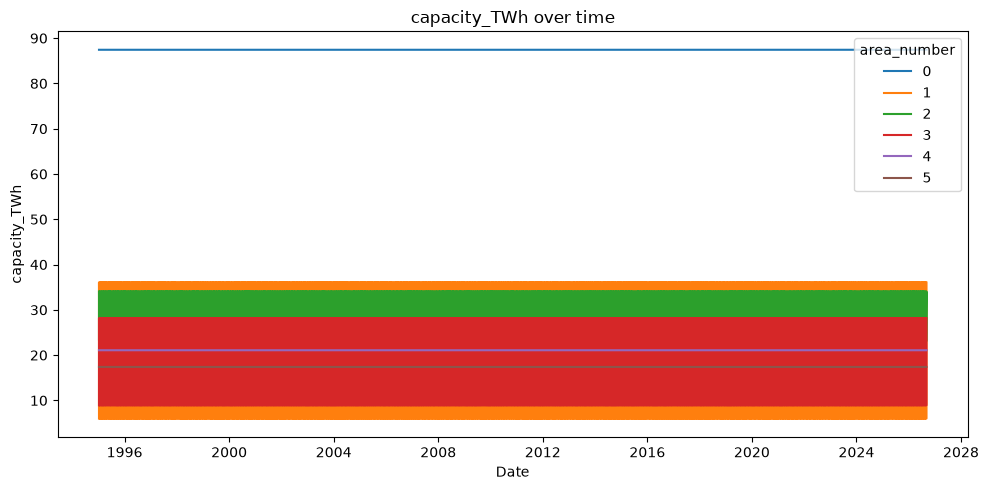

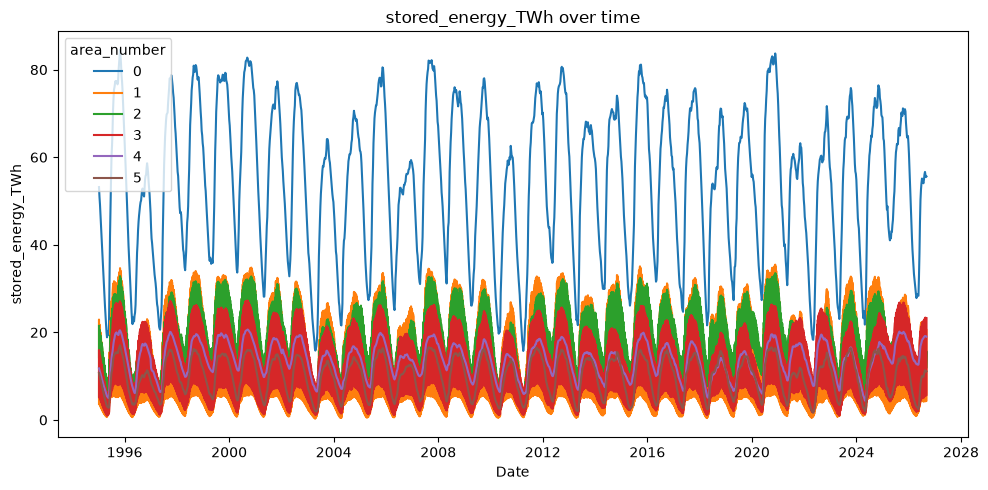

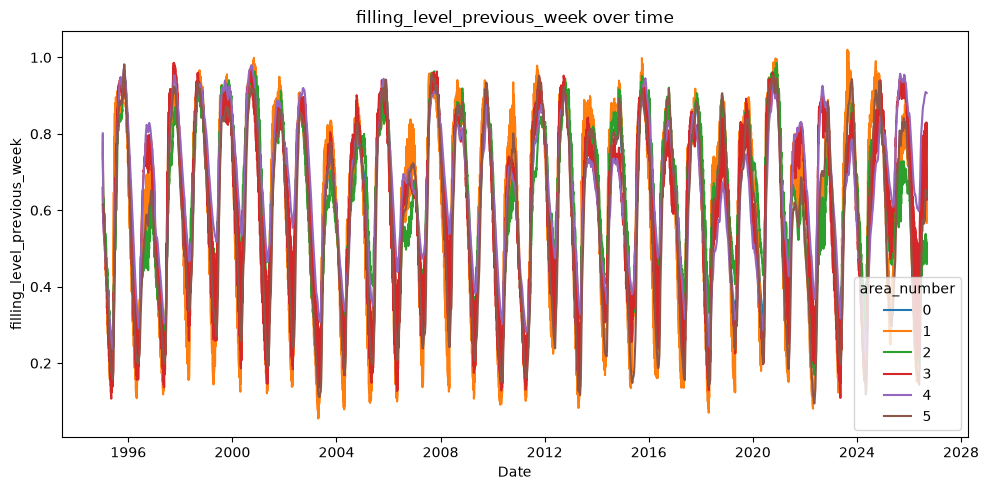

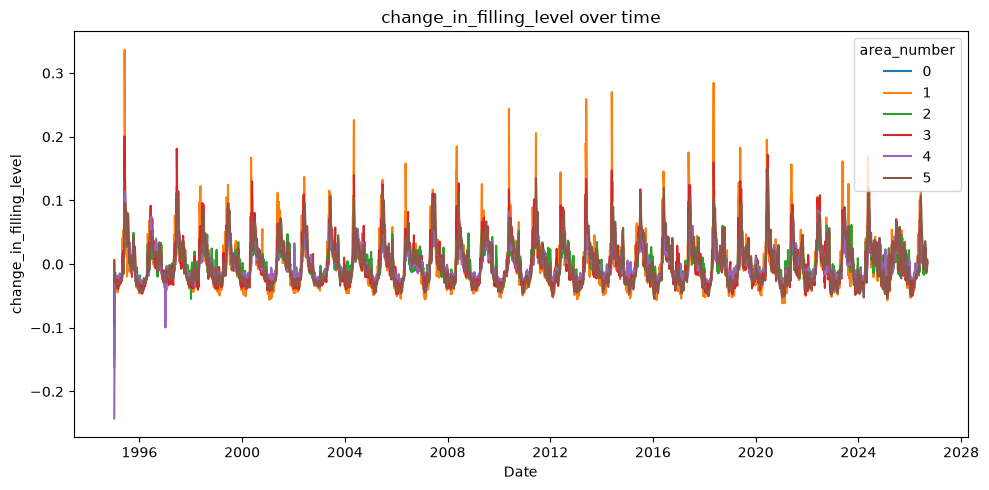

In [18]:
# numerical measurement columns 
line_cols = [
    "filling_level",
    "capacity_TWh",
    "stored_energy_TWh",
    "filling_level_previous_week",
    "change_in_filling_level"
]

# line plots
for col in line_cols:
    plt.figure(figsize=(10, 5))

    # Plot one line for each area number
    for area_number, group in dat.groupby("area_number"):
        plt.plot(
            group["date"],
            group[col],
            label=area_number
        )

    plt.title(f"{col} over time")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.legend(title="area_number")
    plt.tight_layout()
    plt.show()

##### Distributions of categorical and discrete variables 

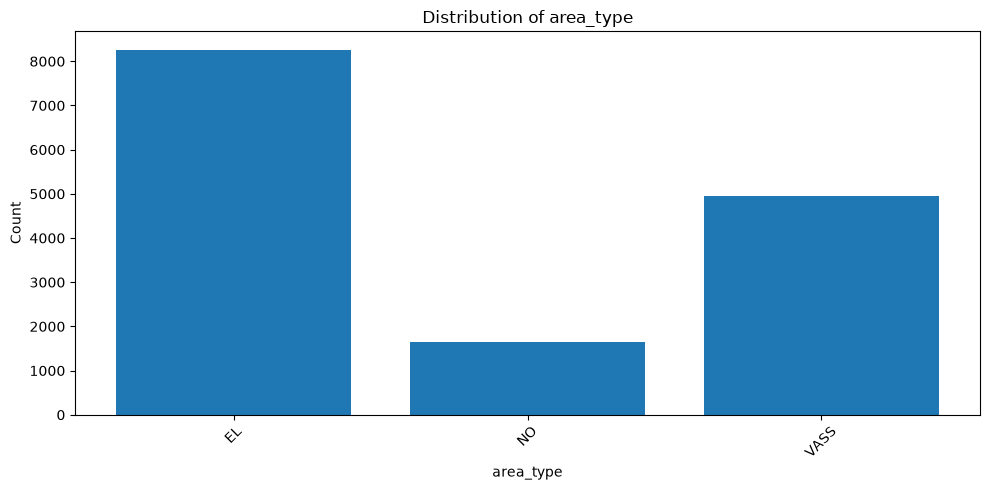

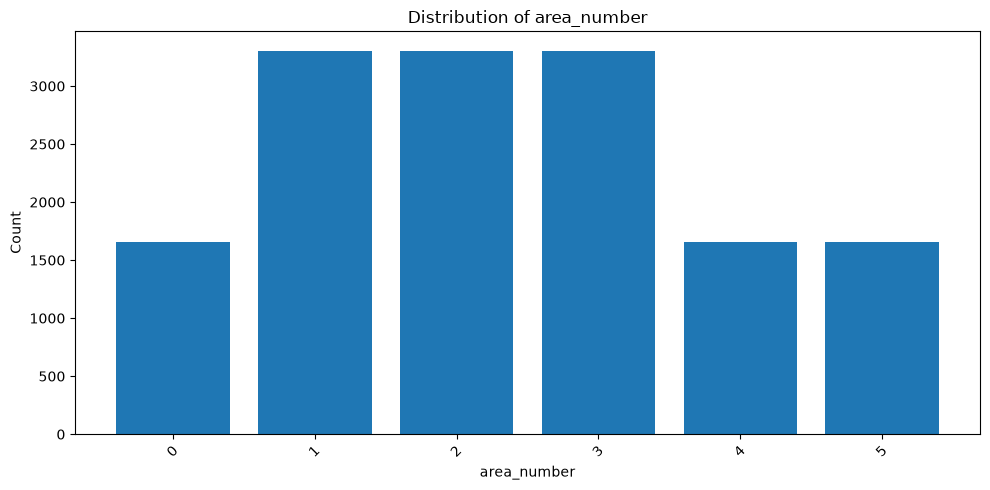

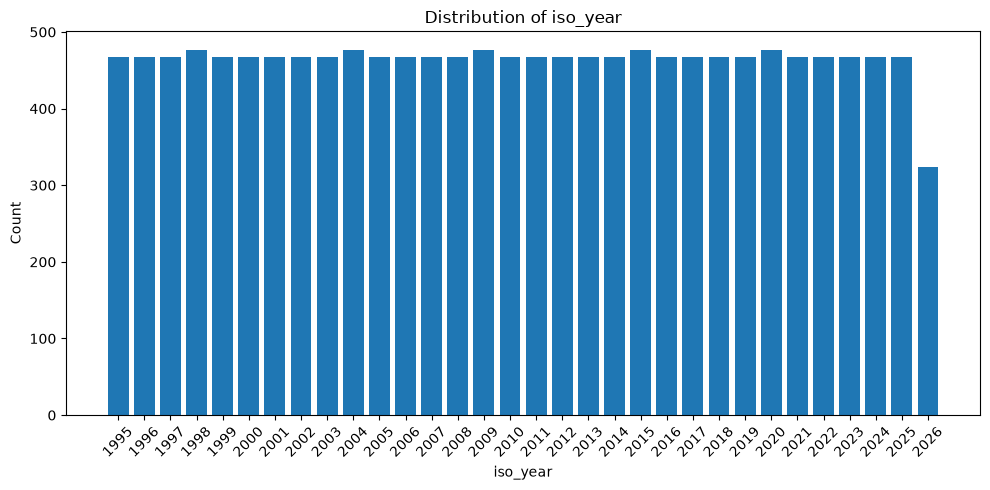

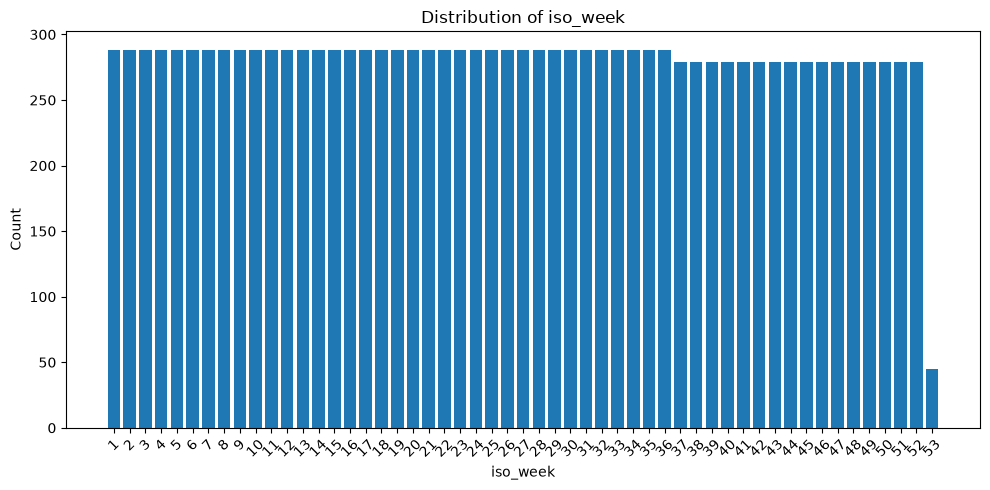

In [19]:
categorical_cols = [
    "area_type",
    "area_number",
    "iso_year",
    "iso_week"
]

for col in categorical_cols:
    # Count observations for each variable
    count_data = (
        dat[col]
        .value_counts()
        .sort_index()
    )

    # Plot variable versus counts
    plt.figure(figsize=(10, 5))

    plt.bar(
        count_data.index.astype(str),
        count_data.values
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Plot of all columns together 

The measurement variables are on different scales, so I scale them before plotting them together. I use min-max scaling to transform each variable to a range between 0 and 1. This makes it easier to compare the patterns of the variables in the same plot.


In [20]:
measure_cols = [
    "filling_level",
    "capacity_TWh",
    "stored_energy_TWh",
    "filling_level_previous_week",
    "change_in_filling_level",
] 

# multiple observations for each date 
plot_data = dat.groupby("date")[measure_cols].mean().reset_index() 


In [21]:
# Min-max scale each measurement column
for col in measure_cols:
    plot_data[col] = (
        (plot_data[col] - plot_data[col].min())
        / (plot_data[col].max() - plot_data[col].min())
    )

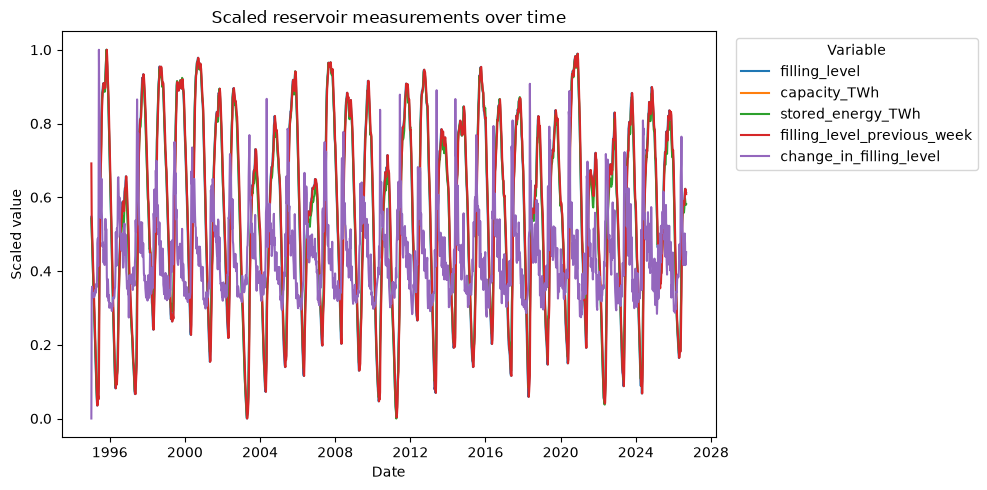

In [22]:
# line plot of all measurement columns
plt.figure(figsize=(10, 5))

for col in measure_cols:
    plt.plot(
        plot_data["date"],
        plot_data[col],
        label=col
    )

plt.title("Scaled reservoir measurements over time")
plt.xlabel("Date")
plt.ylabel("Scaled value")
plt.legend(
    title="Variable",
    bbox_to_anchor=(1.02, 1),
    loc="upper left")
plt.tight_layout()
plt.show()

#### Log (description of compulsory work)

Working with part one of the IND320 project has been both fun and challenging. I had no previous experience with Streamlit or making apps in general, so I have definitely learned a lot.

When working with the notebook, I was first unsure about what kind of data I was working with. After some inspection, googling, and prompting ChatGPT, I learned more about the data. It contains data about Norwegian reservoir levels and stored energy over time. The data contains different area types, including EL, VASS, and NO. The area numbers overlap between the different area types. EL includes area numbers 1 to 5, while VASS contains area numbers 1, 2, and 3. Understanding the data also helped me when translating the column names into meaningful English names.

My biggest challenge while working on the notebook was deciding how to plot the features. When plotting each feature separately, I decided to plot the numerical measurement columns using line plots and use bar plots for the remaining categorical variables. For the combined plot, I decided to only plot the numerical measurement columns. I did not think it made sense to include the features related to time, such as "date", "iso_year", and "iso_week". Since there are several observations for each date, I also had to consider how to handle these observations. I did not do anything about this when plotting the columns separately, but when plotting the measurement columns together, I grouped the data by date and calculated the mean across the different areas. This makes the plot easier to interpret, since I am interested in the overall variation in the variables and differences between the variables rather than the variation for each individual area. I also used min-max scaling before plotting the measurement variables together because they are measured on different scales. When plotting the columns separately, I color the measurement columns according to area number to distinguish between the different area numbers.

When working with the Streamlit app, I used the IND320_student repository as inspiration for how to structure the folders and files. I had no previous experience with Streamlit, so I looked at the lecture notes and completed the class exercises to understand how it works. I also needed some help from ChatGPT to implement features such as st.select_slider and LineChartColumn, in addition to using Google to find information. Making the different pages took some trial and error.

My main challenge was again deciding which columns to include when plotting line charts and which features to include when plotting all columns. I did not think it made sense to plot "iso_year", "iso_week", and "date" as line plots, so I again decided to only plot the measurement columns. On the plot page (page 3), I also decided to plot the mean of the observations for each date when plotting all measurement columns together. When a single variable is selected, I use area_number to distinguish between the different areas in the plot.

Working with Git has gone smoothly. I created a new branch for this assignment and merged it into main when I was finished.


#### Description of AI usage

Prompt to chatGPT: Can you write a short summary about how I have used you in this assignment?

I used ChatGPT as a support tool throughout the project. It was mainly used to help me understand the assignment requirements, translate the original Norwegian variable names into understandable English names, troubleshoot errors, and discuss appropriate ways to visualize the reservoir data. I also used ChatGPT for guidance when developing the Streamlit app, including the page structure, data filtering, interactive widgets, and deployment. The final code was implemented and tested by me, and I used the explanations to better understand the choices made throughout the project.

GitHub Copilot was disabled while I was working on this assignment.